<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-49-random-forest-intuition-code?scriptVersionId=351237288" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background: linear-gradient(135deg, #1a0030 0%, #2d0050 50%, #1a0040 100%); padding: 48px 40px; border-radius: 16px; margin-bottom: 8px; border: 1px solid #4a0080;">
  <div style="display: flex; align-items: center; gap: 12px; margin-bottom: 16px;">
    <span style="background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 2px; padding: 4px 12px; border-radius: 20px; text-transform: uppercase;">ML Series · Episode 49</span>
    <span style="background: rgba(255,255,255,0.08); color: #d8b4fe; font-size: 11px; font-weight: 600; padding: 4px 12px; border-radius: 20px;">From Scratch + sklearn</span>
  </div>
  <h1 style="color: #ffffff; font-size: 38px; font-weight: 800; margin: 0 0 12px 0; line-height: 1.2;">🌲 Random Forest</h1>
  <p style="color: #c084fc; font-size: 16px; margin: 0 0 6px 0; font-style: italic;">"Many different trees. One stronger prediction."</p>
  <p style="color: #e9d5ff; font-size: 15px; margin: 0 0 28px 0; max-width: 700px; line-height: 1.6;">From bootstrap sampling and random feature selection to voting, OOB evaluation, hyperparameter tuning, and feature importance — the complete Random Forest deep dive.</p>
  <div style="display: flex; gap: 20px; flex-wrap: wrap;">
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #4a0080; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #a855f7; font-size: 20px; font-weight: 700;">Bootstrap</div>
      <div style="color: #d8b4fe; font-size: 12px; margin-top: 2px;">Different training samples per tree</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #4a0080; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #a855f7; font-size: 20px; font-weight: 700;">Random Features</div>
      <div style="color: #d8b4fe; font-size: 12px; margin-top: 2px;">More diversity, less correlation</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #4a0080; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #a855f7; font-size: 20px; font-weight: 700;">MNIST</div>
      <div style="color: #d8b4fe; font-size: 12px; margin-top: 2px;">Feature importance as pixel heatmap</div>
    </div>
  </div>
</div>

<div style="background: #0d0020; border-left: 5px solid #a855f7; border-radius: 0 10px 10px 0; padding: 20px 24px; margin: 24px 0; border: 1px solid #4a0080; border-left: 5px solid #a855f7;">
  <h2 style="color: #a855f7; font-size: 15px; font-weight: 700; text-transform: uppercase; letter-spacing: 1.5px; margin: 0 0 10px 0;">📋 Table of Contents</h2>
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 4px;">
    <ol style="margin: 0; padding-left: 20px; color: #c084fc; line-height: 2.1; font-size: 14px;">
      <li><a href='#intro' style='color: #c084fc; text-decoration: none;'>What is Random Forest?</a></li>
      <li><a href='#intuition' style='color: #c084fc; text-decoration: none;'>The Core Intuition</a></li>
      <li><a href='#algorithm' style='color: #c084fc; text-decoration: none;'>The RF Algorithm — Step by Step</a></li>
      <li><a href='#sampling' style='color: #c084fc; text-decoration: none;'>Bootstrap &amp; Feature Sampling (Manual)</a></li>
      <li><a href='#trees' style='color: #c084fc; text-decoration: none;'>3 Trees, 3 Views, Majority Vote</a></li>
      <li><a href='#classification' style='color: #c084fc; text-decoration: none;'>Classification Demo — make_circles</a></li>
      <li><a href='#regression' style='color: #c084fc; text-decoration: none;'>Regression Demo — Noisy Function</a></li>
    </ol>
    <ol start="8" style="margin: 0; padding-left: 20px; color: #c084fc; line-height: 2.1; font-size: 14px;">
      <li><a href='#bagging' style='color: #c084fc; text-decoration: none;'>Bagging vs Random Forest</a></li>
      <li><a href='#tuning' style='color: #c084fc; text-decoration: none;'>Baseline — Heart Disease Dataset</a></li>
      <li><a href='#grid' style='color: #c084fc; text-decoration: none;'>GridSearchCV</a></li>
      <li><a href='#random-search' style='color: #c084fc; text-decoration: none;'>RandomizedSearchCV</a></li>
      <li><a href='#oob' style='color: #c084fc; text-decoration: none;'>OOB Score</a></li>
      <li><a href='#importance' style='color: #c084fc; text-decoration: none;'>Feature Importance — MNIST Pixel Heatmap</a></li>
      <li><a href='#importance-math' style='color: #c084fc; text-decoration: none;'>How Feature Importance Is Calculated</a></li>
    </ol>
  </div>
</div>

<a id='intro'></a>
<div style="border-bottom: 2px solid #a855f7; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 1</span>
  <h2 style="color: #f0e6ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">📌 What is Random Forest?</h2>
</div>

**Random Forest** is an ensemble learning algorithm that builds many Decision Trees and combines their predictions. It was introduced by Leo Breiman in 2001 and is consistently one of the most accurate general-purpose ML algorithms available.

A Random Forest deliberately introduces randomness in **two places**:

<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 14px; margin: 20px 0;">
  <div style="background: #0d0020; border: 1px solid #4a0080; border-radius: 12px; padding: 20px 22px;">
    <div style="color: #a855f7; font-weight: 700; font-size: 13px; margin-bottom: 8px;">🌱 Bootstrap Row Sampling</div>
    <div style="color: #d8b4fe; font-size: 13px; line-height: 1.7;">Each tree is trained on a <strong style='color:#f0e6ff;'>different random sample of rows</strong>, drawn with replacement from the training set. ~63% of rows are unique; ~37% are OOB (never selected for that tree).</div>
  </div>
  <div style="background: #0d0020; border: 1px solid #4a0080; border-radius: 12px; padding: 20px 22px;">
    <div style="color: #a855f7; font-weight: 700; font-size: 13px; margin-bottom: 8px;">🎲 Random Feature Subsets at Each Split</div>
    <div style="color: #d8b4fe; font-size: 13px; line-height: 1.7;">At <strong style='color:#f0e6ff;'>every node</strong> inside each tree, only a random subset of features (typically √p for classification, p/3 for regression) is considered for the split. This is the key difference from plain Bagging.</div>
  </div>
</div>

<div style="background: #0d0020; border: 1px solid #4a0080; border-radius: 10px; padding: 18px 22px; margin: 14px 0; text-align: center; font-family: Georgia, serif; font-size: 16px; color: #f0e6ff;">
  🌳 + 🌳 + 🌳 + ... + 🌳 &nbsp;→&nbsp; 🌲 <strong style='color:#a855f7;'>Random Forest</strong><br/>
  <span style="font-size: 13px; color: #d8b4fe;">Classification → majority vote &nbsp;·&nbsp; Regression → average predictions</span>
</div>

<div style="background: #0d0020; border-left: 4px solid #a855f7; border-radius: 0 8px 8px 0; padding: 12px 18px; margin: 14px 0; font-size: 14px; color: #d8b4fe;">
  <strong style="color: #f0e6ff;">💡 Core idea:</strong> Randomness creates diverse trees that make <em>different</em> errors. When you average their predictions, those errors cancel out — leaving a stable, accurate ensemble.
</div>

<a id='intuition'></a>
<div style="border-bottom: 2px solid #a855f7; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 2</span>
  <h2 style="color: #f0e6ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🧠 The Core Intuition</h2>
</div>

Imagine one Decision Tree makes an unstable split because it happened to see certain training rows. Change a few rows and the tree structure might change completely — that's high variance. What happens when we build many different trees, each trained from a slightly different view of the data, and combine their predictions?

<div style="background: #0d0020; border: 1px solid #4a0080; border-radius: 12px; padding: 22px 28px; margin: 20px 0;">
  <div style="color: #d8b4fe; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 16px;">From One Model to an Ensemble</div>
  <div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 14px;">
    <div style="text-align: center; border: 1px solid #4a0080; border-radius: 10px; padding: 16px;">
      <div style="font-size: 28px; margin-bottom: 8px;">🌳</div>
      <div style="color: #a855f7; font-weight: 700; font-size: 13px; margin-bottom: 6px;">Single Tree</div>
      <div style="color: #d8b4fe; font-size: 12px; line-height: 1.6;">High variance — very sensitive to which training rows it sees. Change 5% of data → completely different tree.</div>
    </div>
    <div style="text-align: center; border: 2px solid #a855f7; border-radius: 10px; padding: 16px;">
      <div style="font-size: 28px; margin-bottom: 8px;">🌲🌲🌲</div>
      <div style="color: #a855f7; font-weight: 700; font-size: 13px; margin-bottom: 6px;">Diverse Trees</div>
      <div style="color: #d8b4fe; font-size: 12px; line-height: 1.6;">Bootstrap + random features = each tree sees the data differently → trees disagree in different places.</div>
    </div>
    <div style="text-align: center; border: 1px solid #4a0080; border-radius: 10px; padding: 16px;">
      <div style="font-size: 28px; margin-bottom: 8px;">🗳️</div>
      <div style="color: #a855f7; font-weight: 700; font-size: 13px; margin-bottom: 6px;">Aggregate</div>
      <div style="color: #d8b4fe; font-size: 12px; line-height: 1.6;">Errors cancel out. Majority wins for classification; mean for regression. Variance drops by ~1/N.</div>
    </div>
  </div>
</div>

<a id='algorithm'></a>
<div style="border-bottom: 2px solid #a855f7; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 3</span>
  <h2 style="color: #f0e6ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">⚙️ The Random Forest Algorithm — Step by Step</h2>
</div>

<div style="background: #0d0020; border: 1px solid #4a0080; border-radius: 12px; padding: 24px 30px; margin: 20px 0;">
  <div style="display: flex; flex-direction: column; gap: 14px;">
    <div style="display: flex; gap: 14px; align-items: flex-start;">
      <span style="background: #a855f7; color: #fff; font-weight: 700; font-size: 12px; padding: 3px 10px; border-radius: 10px; white-space: nowrap; margin-top: 2px;">For t=1…T</span>
      <span style="color: #d8b4fe; font-size: 13px; line-height: 1.7;">Repeat for each of the T trees in the forest:</span>
    </div>
    <div style="display: flex; gap: 14px; align-items: flex-start; margin-left: 16px;">
      <span style="background: rgba(168,85,247,0.3); color: #e9d5ff; font-weight: 700; font-size: 11px; padding: 2px 8px; border-radius: 8px; white-space: nowrap; margin-top: 2px;">Step A</span>
      <span style="color: #d8b4fe; font-size: 13px;"><strong style='color:#f0e6ff;'>Bootstrap sample</strong> — draw N rows with replacement from the training set. ~63% are unique original rows; the excluded ~37% are OOB for this tree.</span>
    </div>
    <div style="display: flex; gap: 14px; align-items: flex-start; margin-left: 16px;">
      <span style="background: rgba(168,85,247,0.3); color: #e9d5ff; font-weight: 700; font-size: 11px; padding: 2px 8px; border-radius: 8px; white-space: nowrap; margin-top: 2px;">Step B</span>
      <span style="color: #d8b4fe; font-size: 13px;"><strong style='color:#f0e6ff;'>Grow a full Decision Tree</strong> on the bootstrap sample, but at each node, only consider <strong style='color:#a855f7;'>m = √p</strong> (classification) or <strong style='color:#a855f7;'>m = p/3</strong> (regression) randomly chosen features.</span>
    </div>
    <div style="display: flex; gap: 14px; align-items: flex-start; margin-left: 16px;">
      <span style="background: rgba(168,85,247,0.3); color: #e9d5ff; font-weight: 700; font-size: 11px; padding: 2px 8px; border-radius: 8px; white-space: nowrap; margin-top: 2px;">Step C</span>
      <span style="color: #d8b4fe; font-size: 13px;"><strong style='color:#f0e6ff;'>No pruning</strong> — trees grow to maximum depth. Individual trees overfit, but the ensemble averages this out.</span>
    </div>
    <div style="display: flex; gap: 14px; align-items: flex-start;">
      <span style="background: #a855f7; color: #fff; font-weight: 700; font-size: 12px; padding: 3px 10px; border-radius: 10px; white-space: nowrap; margin-top: 2px;">Predict</span>
      <span style="color: #d8b4fe; font-size: 13px;">Classification: <strong style='color:#f0e6ff;'>majority vote</strong> across all T trees. Regression: <strong style='color:#f0e6ff;'>average</strong> of all T predictions.</span>
    </div>
  </div>
  <div style="margin-top: 14px; padding-top: 12px; border-top: 1px solid #4a0080; display: grid; grid-template-columns: 1fr 1fr; gap: 12px; font-size: 12px; color: #d8b4fe;">
    <div><strong style='color:#a855f7;'>Default max_features:</strong> <code>'sqrt'</code> for classification, <code>'1.0'</code> for regression in sklearn</div>
    <div><strong style='color:#a855f7;'>Why no pruning?</strong> High-variance individual trees benefit from the ensemble — pruning would reduce diversity</div>
  </div>
</div>

<a id='sampling'></a>
<div style="border-bottom: 2px solid #a855f7; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 4</span>
  <h2 style="color: #f0e6ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🎲 Bootstrap &amp; Feature Sampling — Manual Demo</h2>
</div>

Before using sklearn's `RandomForestClassifier`, we build the sampling mechanism from scratch. These three helper functions expose what happens inside the forest: each tree gets a different view of the data via both row and column sampling.

<div style="background: #0d0020; border: 1px solid #4a0080; border-radius: 8px; padding: 14px 20px; margin: 14px 0; font-size: 13px; color: #d8b4fe;">
  <strong style="color: #a855f7;">⚠️ Teaching demo caveat:</strong> In a production Random Forest, feature randomness is applied at <strong style='color:#f0e6ff;'>every split node</strong> inside each tree (controlled by <code>max_features</code>). The demo below applies it once per tree for simplicity — it illustrates the idea but is not how sklearn's implementation works.
</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                               BaggingClassifier, GradientBoostingClassifier)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification, make_circles
from sklearn.metrics import accuracy_score

random.seed(42)
np.random.seed(42)
print("Imports complete.")

Imports complete.


In [2]:
# Toy dataset: 100 samples, 5 features, no redundancy
X, y = make_classification(n_features=5, n_redundant=0, n_informative=5,
                            n_clusters_per_class=1, random_state=42)

df = pd.DataFrame(X, columns=['col1','col2','col3','col4','col5'])
df['target'] = y

print(f"Dataset shape: {df.shape}")
print(f"Class balance: {df['target'].value_counts().to_dict()}")
df.head()

Dataset shape: (100, 6)
Class balance: {0: 50, 1: 50}


,col1,col2,col3,col4,col5,target
0,1.053909,-3.861208,1.530963,0.596692,1.030284,0
1,3.243492,1.666651,3.179016,-0.825861,0.778528,1
2,0.712446,-1.201617,1.528624,-0.422788,-0.376825,0
3,1.388329,1.538995,1.243716,0.740905,-2.081063,1
4,2.394647,-3.576345,0.914217,0.363136,2.110329,0


In [3]:
def sample_rows(df, percent):
    """Bootstrap row sampling — WITH replacement. ~37% of rows will be OOB."""
    n = int(percent * df.shape[0])
    return df.sample(n, replace=True)

def sample_features(df, percent):
    """Randomly select a subset of feature columns (excluding target)."""
    feature_cols = df.columns.tolist()[:-1]          # exclude 'target'
    n_cols = int(percent * len(feature_cols))
    selected = random.sample(feature_cols, n_cols)
    new_df = df[selected].copy()
    new_df['target'] = df['target'].to_numpy()
    return new_df

def combined_sampling(df, row_percent, col_percent):
    """Apply both row bootstrap AND feature sampling — the essence of RF diversity."""
    return sample_features(sample_rows(df, row_percent), col_percent)

print("Sampling functions defined.")

Sampling functions defined.


In [4]:
# Generate 3 different sampled views of the data
df1 = combined_sampling(df, 0.5, 0.5)   # 50 rows, 2-3 features
df2 = combined_sampling(df, 0.5, 0.5)
df3 = combined_sampling(df, 0.5, 0.5)

print("Feature columns each tree will see:")
print(f"  Tree 1: {df1.columns.tolist()}")
print(f"  Tree 2: {df2.columns.tolist()}")
print(f"  Tree 3: {df3.columns.tolist()}")
print(f"\nRow counts: {df1.shape[0]}, {df2.shape[0]}, {df3.shape[0]}")
print("(note: different features → different information → different trees)")

Feature columns each tree will see:
  Tree 1: ['col1', 'col5', 'target']
  Tree 2: ['col3', 'col2', 'target']
  Tree 3: ['col2', 'col5', 'target']

Row counts: 50, 50, 50
(note: different features → different information → different trees)


<a id='trees'></a>
<div style="border-bottom: 2px solid #a855f7; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 5</span>
  <h2 style="color: #f0e6ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🌳 3 Trees, 3 Views — Majority Vote</h2>
</div>

Each tree is trained on a different sampled dataset — different rows, different features. We then ask each tree to predict the same query point. If the trees disagree, the **majority wins**. This is the entire aggregation step of a Random Forest.

In [5]:
clf1 = DecisionTreeClassifier(random_state=42)
clf2 = DecisionTreeClassifier(random_state=42)
clf3 = DecisionTreeClassifier(random_state=42)

# Each tree trained on its own sampled dataset
clf1.fit(df1.iloc[:, :2], df1.iloc[:, -1])   # first 2 feature cols, target
clf2.fit(df2.iloc[:, :2], df2.iloc[:, -1])
clf3.fit(df3.iloc[:, :2], df3.iloc[:, -1])

print("Three trees trained. Visualising their structures...")

Three trees trained. Visualising their structures...


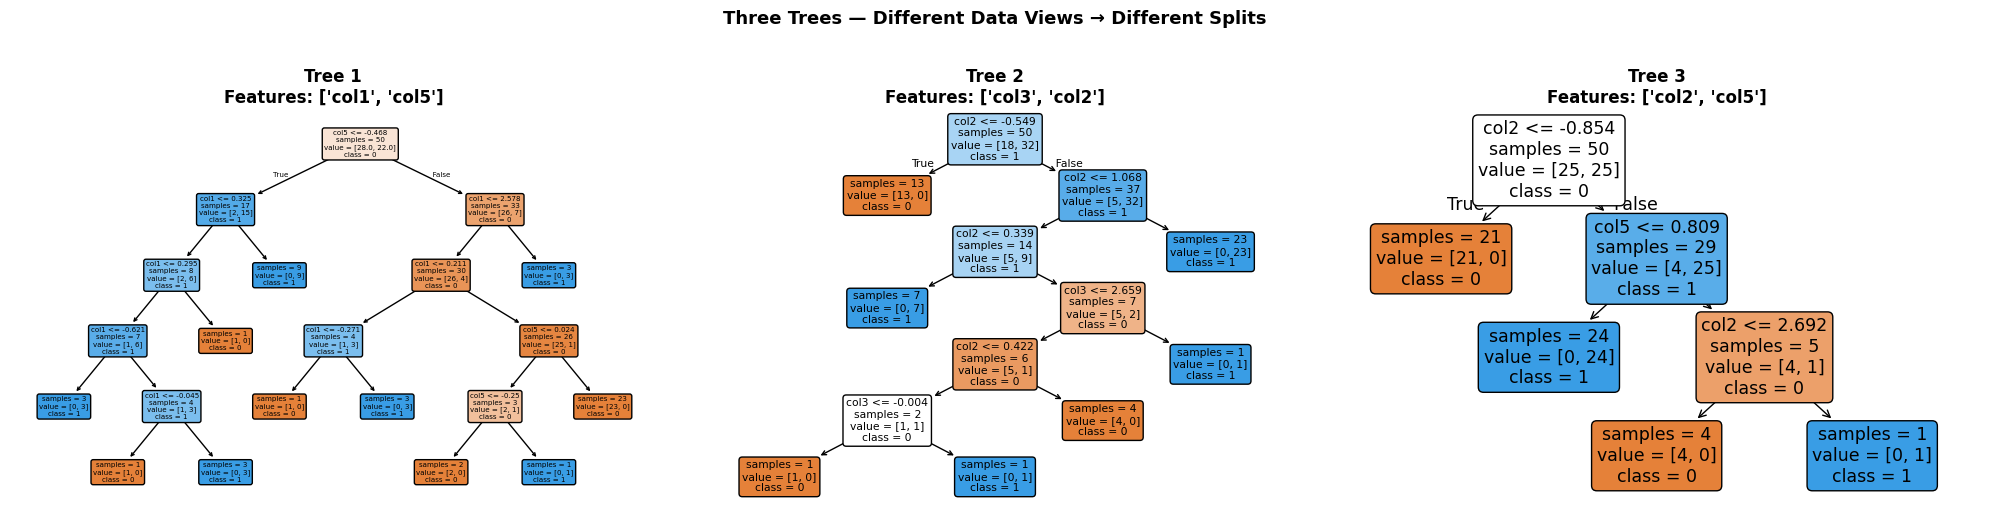

In [6]:
# Show all 3 tree structures side-by-side
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, clf, dfX, title in zip(
    axes,
    [clf1, clf2, clf3],
    [df1, df2, df3],
    ['Tree 1', 'Tree 2', 'Tree 3']
):
    plot_tree(clf, feature_names=dfX.columns[:2].tolist(),
              class_names=['0', '1'], filled=True, rounded=True,
              impurity=False, ax=ax)
    ax.set_title(f'{title}\nFeatures: {dfX.columns[:2].tolist()}',
                 fontweight='bold')

plt.suptitle('Three Trees — Different Data Views → Different Splits',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# Query point — same input, 3 different predictions
query_val = [-1.042498, -0.064323]

df1_input = pd.DataFrame([query_val], columns=df1.columns[:2])
df2_input = pd.DataFrame([query_val], columns=df2.columns[:2])
df3_input = pd.DataFrame([query_val], columns=df3.columns[:2])

pred1 = int(clf1.predict(df1_input)[0])
pred2 = int(clf2.predict(df2_input)[0])
pred3 = int(clf3.predict(df3_input)[0])

# Majority vote — the forest's final answer
tree_preds = [pred1, pred2, pred3]
forest_pred = max(set(tree_preds), key=tree_preds.count)

print(f"Query: {query_val}")
print(f"{'='*35}")
print(f"  Tree 1 (features {df1.columns[:2].tolist()}) → {pred1}")
print(f"  Tree 2 (features {df2.columns[:2].tolist()}) → {pred2}")
print(f"  Tree 3 (features {df3.columns[:2].tolist()}) → {pred3}")
print(f"{'='*35}")
print(f"  Majority vote → Class {forest_pred}")

Query: [-1.042498, -0.064323]
  Tree 1 (features ['col1', 'col5']) → 0
  Tree 2 (features ['col3', 'col2']) → 1
  Tree 3 (features ['col2', 'col5']) → 0
  Majority vote → Class 0


<div style="background: #0d0020; border-left: 4px solid #a855f7; border-radius: 0 8px 8px 0; padding: 12px 18px; margin: 12px 0; font-size: 14px; color: #d8b4fe;">
  <strong style="color: #f0e6ff;">✅ This is the forest:</strong> A production RandomForestClassifier does exactly this, but with 100–500 trees instead of 3, and applies feature randomness at <em>each split node</em> rather than once per tree. Everything else is the same principle.
</div>

<a id='classification'></a>
<div style="border-bottom: 2px solid #a855f7; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 6</span>
  <h2 style="color: #f0e6ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🧪 Classification Demo — make_circles</h2>
</div>

We use `make_circles` — two concentric rings — as a non-linear classification problem. A single Decision Tree creates jagged, data-specific boundaries. A Random Forest of 500 trees produces a much smoother, more reliable decision region.

<div style="background: #0d0020; border: 1px solid #4a0080; border-radius: 8px; padding: 14px 20px; margin: 14px 0; font-size: 13px; color: #d8b4fe;">
  <strong style="color: #a855f7;">What to look for:</strong> The single tree's boundary is angular and sample-specific — it would change significantly with different training data. The forest's boundary is smoother and more generalised — it represents the consensus of 500 different trees, each having seen a slightly different data slice.
</div>

Train: (375, 2)  |  Test: (125, 2)


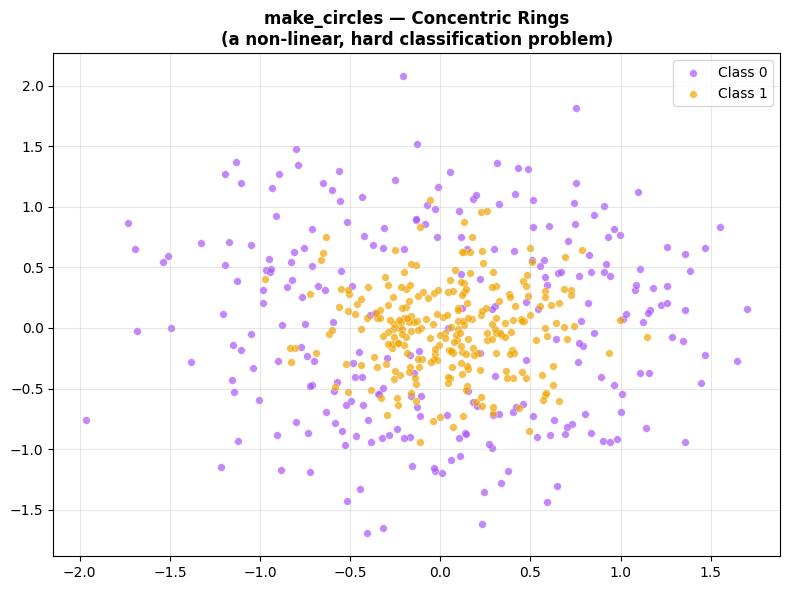

In [8]:
np.random.seed(42)
X_c, y_c = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, random_state=42)

print(f"Train: {X_train_c.shape}  |  Test: {X_test_c.shape}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_c[y_c==0, 0], X_c[y_c==0, 1], c='#a855f7', s=30, alpha=0.7,
           edgecolors='white', linewidth=0.3, label='Class 0')
ax.scatter(X_c[y_c==1, 0], X_c[y_c==1, 1], c='#f0a500', s=30, alpha=0.7,
           edgecolors='white', linewidth=0.3, label='Class 1')
ax.set_title('make_circles — Concentric Rings\n(a non-linear, hard classification problem)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

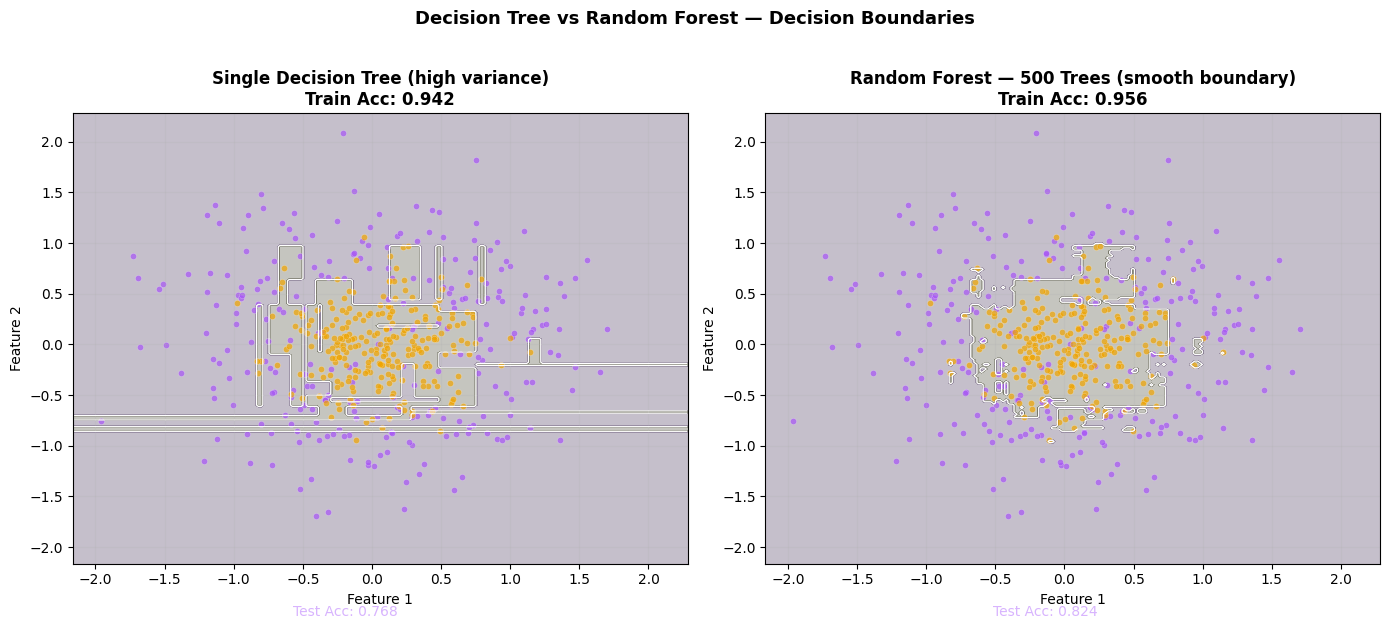

In [9]:
from matplotlib.colors import ListedColormap

def plot_boundary(clf, X, y, title, ax):
    """Plot a 2D decision boundary for any fitted classifier."""
    x_range = np.linspace(X.min() - 0.2, X.max() + 0.2, 200)
    xx1, xx2 = np.meshgrid(x_range, x_range)
    Z = clf.predict(np.c_[xx1.ravel(), xx2.ravel()]).reshape(xx1.shape)
    ax.contourf(xx1, xx2, Z, alpha=0.25,
                cmap=ListedColormap(['#1a0030', '#1a1a00']))
    ax.contour(xx1, xx2, Z, colors='white', linewidths=1.0, levels=[0.5])
    ax.scatter(X[y==0, 0], X[y==0, 1], c='#a855f7', s=20, alpha=0.7,
               edgecolors='white', linewidth=0.2)
    ax.scatter(X[y==1, 0], X[y==1, 1], c='#f0a500', s=20, alpha=0.7,
               edgecolors='white', linewidth=0.2)
    acc = accuracy_score(y, clf.predict(X))
    ax.set_title(f'{title}\nTrain Acc: {acc:.3f}', fontweight='bold')
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
    ax.grid(True, alpha=0.2)

# Single tree vs Random Forest
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train_c, y_train_c)

rf500 = RandomForestClassifier(n_estimators=500, random_state=42)
rf500.fit(X_train_c, y_train_c)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_boundary(dtree, X_c, y_c, 'Single Decision Tree (high variance)', axes[0])
plot_boundary(rf500, X_c, y_c, 'Random Forest — 500 Trees (smooth boundary)', axes[1])

# Add test accuracy
dt_test = accuracy_score(y_test_c, dtree.predict(X_test_c))
rf_test = accuracy_score(y_test_c, rf500.predict(X_test_c))
fig.text(0.25, 0.01, f'Test Acc: {dt_test:.3f}', ha='center', fontsize=10, color='#d8b4fe')
fig.text(0.75, 0.01, f'Test Acc: {rf_test:.3f}', ha='center', fontsize=10, color='#d8b4fe')

plt.suptitle('Decision Tree vs Random Forest — Decision Boundaries',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<a id='regression'></a>
<div style="border-bottom: 2px solid #a855f7; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 7</span>
  <h2 style="color: #f0e6ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">📈 Regression Demo — Noisy Function</h2>
</div>

Random Forest also handles regression by **averaging predictions** across all trees instead of voting. A single tree's prediction is a jagged piecewise-constant function — each leaf gives a flat prediction. Averaging many such functions produces a much smoother, more accurate estimate.

We fit a target function `f(x) = exp(−x²) + 1.5·exp(−(x−2)²)` on 150 noisy training points and evaluate on 1000 test points.

In [10]:
def f(x):
    x = x.ravel()
    return np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2)

def generate(n_samples, noise=0.1):
    X = np.sort(np.random.rand(n_samples) * 10 - 5).reshape(-1, 1)
    y = f(X) + np.random.normal(0, noise, n_samples)
    return X, y

X_train_r, y_train_r = generate(150, noise=0.1)
X_test_r,  y_test_r  = generate(1000, noise=0.1)

# Train both
dtree_r = DecisionTreeRegressor(random_state=42).fit(X_train_r, y_train_r)
rfr     = RandomForestRegressor(n_estimators=1000, random_state=42).fit(X_train_r, y_train_r)

d_pred  = dtree_r.predict(X_test_r)
rf_pred = rfr.predict(X_test_r)

mse_dt = np.mean((y_test_r - d_pred)**2)
mse_rf = np.mean((y_test_r - rf_pred)**2)

print(f"Decision Tree MSE : {mse_dt:.4f}")
print(f"Random Forest MSE : {mse_rf:.4f}")
print(f"Improvement       : {(mse_dt - mse_rf) / mse_dt * 100:.1f}% lower MSE")

Decision Tree MSE : 0.0193
Random Forest MSE : 0.0143
Improvement       : 26.0% lower MSE


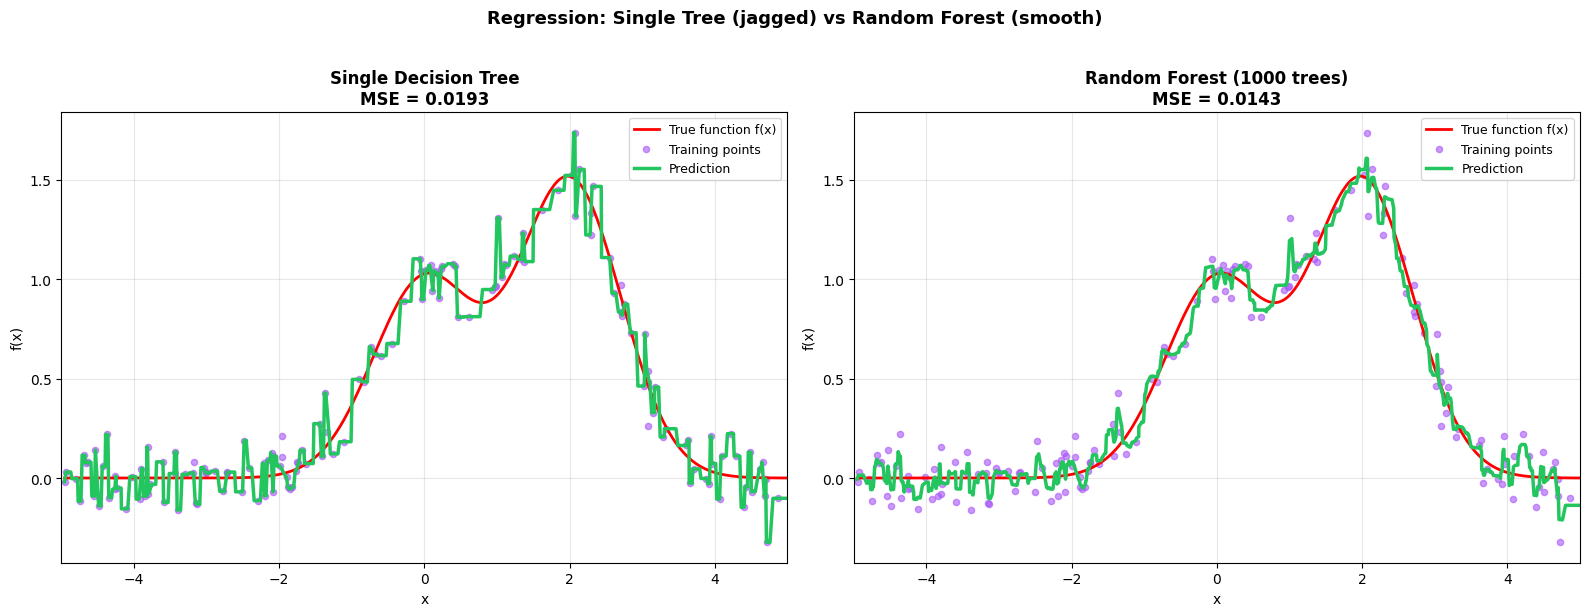

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, pred, mse, title in zip(
    axes,
    [d_pred, rf_pred],
    [mse_dt, mse_rf],
    ['Single Decision Tree', 'Random Forest (1000 trees)']
):
    ax.plot(X_test_r, f(X_test_r), 'r-', linewidth=2, label='True function f(x)')
    ax.scatter(X_train_r, y_train_r, c='#a855f7', s=20, alpha=0.6, label='Training points')
    ax.plot(X_test_r, pred, '#22c55e', linewidth=2.5, label='Prediction')
    ax.set_xlim([-5, 5])
    ax.set_title(f'{title}\nMSE = {mse:.4f}', fontweight='bold')
    ax.set_xlabel('x'); ax.set_ylabel('f(x)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Regression: Single Tree (jagged) vs Random Forest (smooth)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<a id='bagging'></a>
<div style="border-bottom: 2px solid #a855f7; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 8</span>
  <h2 style="color: #f0e6ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🧺 Bagging vs Random Forest</h2>
</div>

Random Forest is a specialised form of Bagging with one critical addition: **feature randomness applied at each split**. This extra randomness further decorrelates the trees — the key reason Random Forest almost always outperforms plain Bagging with Decision Trees.

<div style="background: #0d0020; border: 1px solid #4a0080; border-radius: 10px; overflow: hidden; margin: 16px 0;">
  <table style="width: 100%; border-collapse: collapse; font-size: 13px;">
    <thead>
      <tr style="background: #2d0050;">
        <th style="padding: 11px 16px; color: #a855f7; text-align: left;">Method</th>
        <th style="padding: 11px 16px; color: #a855f7; text-align: center;">Bootstrap rows</th>
        <th style="padding: 11px 16px; color: #a855f7; text-align: center;">Feature randomness</th>
        <th style="padding: 11px 16px; color: #a855f7; text-align: left;">When applied</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom: 1px solid #4a0080;">
        <td style="padding: 10px 16px; font-weight: 700; color: #f0e6ff;">Bagging</td>
        <td style="padding: 10px 16px; color: #d8b4fe; text-align: center;">✅</td>
        <td style="padding: 10px 16px; color: #d8b4fe; text-align: center;">Optional</td>
        <td style="padding: 10px 16px; color: #d8b4fe;">Once per tree (if at all)</td>
      </tr>
      <tr style="background: rgba(168,85,247,0.06);">
        <td style="padding: 10px 16px; font-weight: 700; color: #f0e6ff;">Random Forest ✦</td>
        <td style="padding: 10px 16px; color: #d8b4fe; text-align: center;">✅</td>
        <td style="padding: 10px 16px; color: #d8b4fe; text-align: center;">✅ Always</td>
        <td style="padding: 10px 16px; color: #d8b4fe;"><strong style='color:#a855f7;'>At every node split</strong> inside each tree</td>
      </tr>
    </tbody>
  </table>
</div>

In [12]:
X_b, y_b = make_classification(n_features=5, n_redundant=0, n_informative=5,
                                n_clusters_per_class=1, random_state=42)
df_b = pd.DataFrame(X_b, columns=['col1','col2','col3','col4','col5'])
df_b['target'] = y_b

# Bagging: feature subset is selected ONCE per base estimator
bag = BaggingClassifier(max_features=2, n_estimators=50, random_state=42)
bag.fit(df_b.iloc[:, :5], df_b.iloc[:, -1])

# Random Forest: max_features applied at EVERY SPLIT of each tree
rf_b = RandomForestClassifier(max_features=2, n_estimators=50, random_state=42)
rf_b.fit(df_b.iloc[:, :5], df_b.iloc[:, -1])

bag_cv = cross_val_score(bag, df_b.iloc[:,:5], df_b.iloc[:,-1], cv=5).mean()
rf_cv  = cross_val_score(rf_b, df_b.iloc[:,:5], df_b.iloc[:,-1], cv=5).mean()

print(f"BaggingClassifier   CV Acc (5-fold): {bag_cv:.4f}")
print(f"RandomForestClassifier CV Acc:       {rf_cv:.4f}")
print(f"\n→ RF usually wins because per-split feature randomness creates more diversity.")

BaggingClassifier   CV Acc (5-fold): 0.9200
RandomForestClassifier CV Acc:       0.9500

→ RF usually wins because per-split feature randomness creates more diversity.


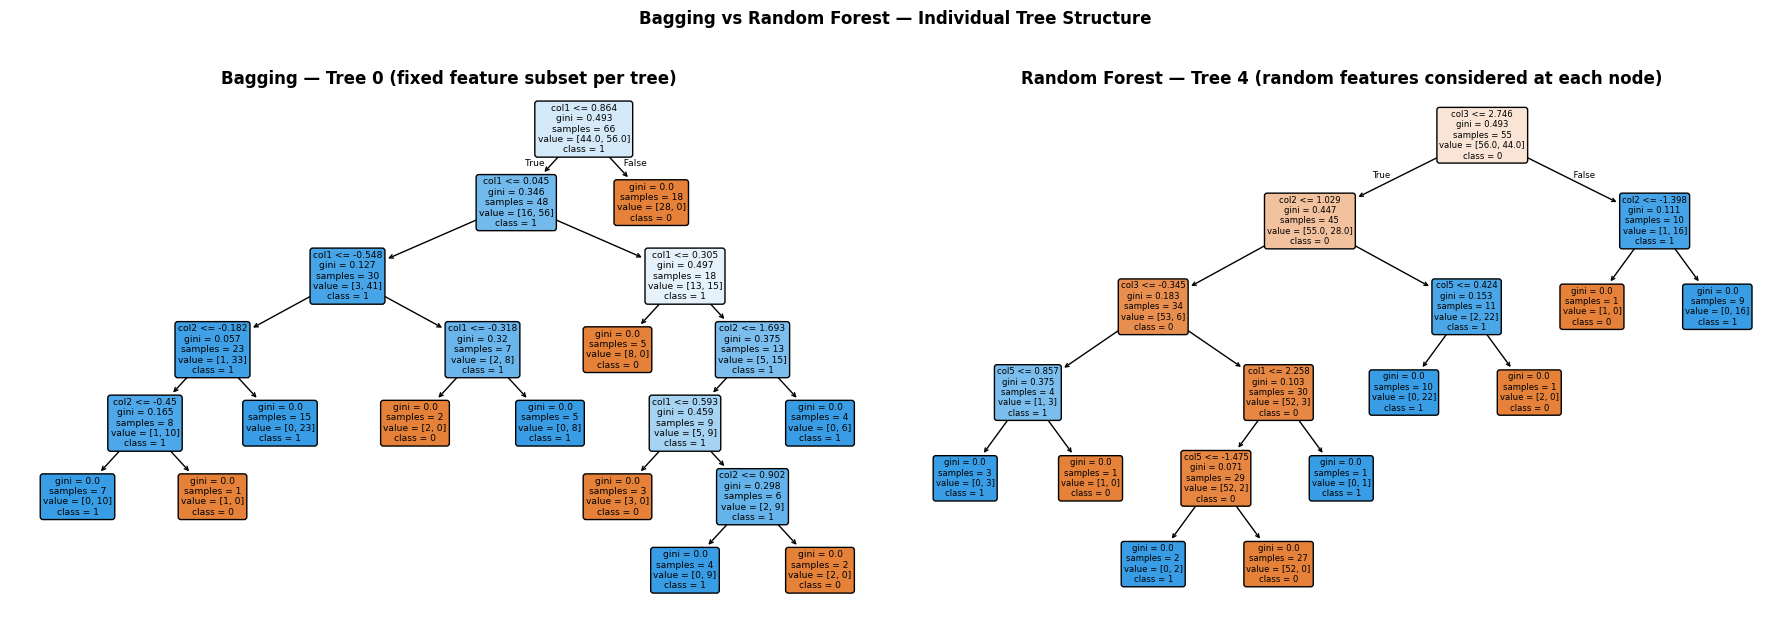

In [13]:
# Inspect an individual tree from each ensemble to see structure differences
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plot_tree(bag.estimators_[0], feature_names=['col1','col2'], class_names=['0','1'],
          filled=True, rounded=True, ax=axes[0])
axes[0].set_title('Bagging — Tree 0 (fixed feature subset per tree)', fontweight='bold')

plot_tree(rf_b.estimators_[4], feature_names=['col1','col2','col3','col4','col5'],
          class_names=['0','1'], filled=True, rounded=True, ax=axes[1])
axes[1].set_title('Random Forest — Tree 4 (random features considered at each node)', fontweight='bold')

plt.suptitle('Bagging vs Random Forest — Individual Tree Structure', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<a id='tuning'></a>
<div style="border-bottom: 2px solid #a855f7; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 9</span>
  <h2 style="color: #f0e6ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🏥 Baseline — Heart Disease Dataset</h2>
</div>

We now move to a real dataset: the **Cleveland Heart Disease** dataset (303 patients, 13 clinical features). The binary target indicates presence of heart disease. We establish baseline accuracy for 4 classifiers before tuning.

<div style="background: #0d0020; border: 1px solid #4a0080; border-radius: 8px; padding: 14px 20px; margin: 14px 0; font-size: 13px; color: #d8b4fe;">
  <strong style="color: #a855f7;">Key Random Forest hyperparameters:</strong><br/>
  <code>n_estimators</code> — number of trees (more = better, until diminishing returns) ·
  <code>max_features</code> — features per split (default √p) ·
  <code>max_depth</code> — depth limit per tree ·
  <code>max_samples</code> — fraction of rows per tree ·
  <code>min_samples_leaf</code> — controls leaf size (regularisation)
</div>

In [14]:
df_heart = pd.read_csv('/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv')

print(f"Shape : {df_heart.shape}")
print(f"Target: {df_heart['target'].value_counts().to_dict()}")
df_heart.head()

Shape : (1025, 14)
Target: {1: 526, 0: 499}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [15]:
X_h = df_heart.drop(columns=['target'])
y_h = df_heart['target']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42
)
print(f"Train: {X_train_h.shape}  |  Test: {X_test_h.shape}")

# Four baseline classifiers
models = {
    'Random Forest':       RandomForestClassifier(random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
    'SVC':                 SVC(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
}

print(f"\n{'Model':<25} {'Test Acc':>10} {'CV Mean':>10}")
print("-" * 47)
baseline_accs = {}
for name, m in models.items():
    m.fit(X_train_h, y_train_h)
    acc = accuracy_score(y_test_h, m.predict(X_test_h))
    cv  = cross_val_score(m, X_h, y_h, cv=10, scoring='accuracy').mean()
    baseline_accs[name] = acc
    print(f"{name:<25} {acc:>10.4f} {cv:>10.4f}")

Train: (820, 13)  |  Test: (205, 13)

Model                       Test Acc    CV Mean
-----------------------------------------------
Random Forest                 0.9854     0.9971
Gradient Boosting             0.9317     0.9707
SVC                           0.6829     0.6897
Logistic Regression           0.7951     0.8448


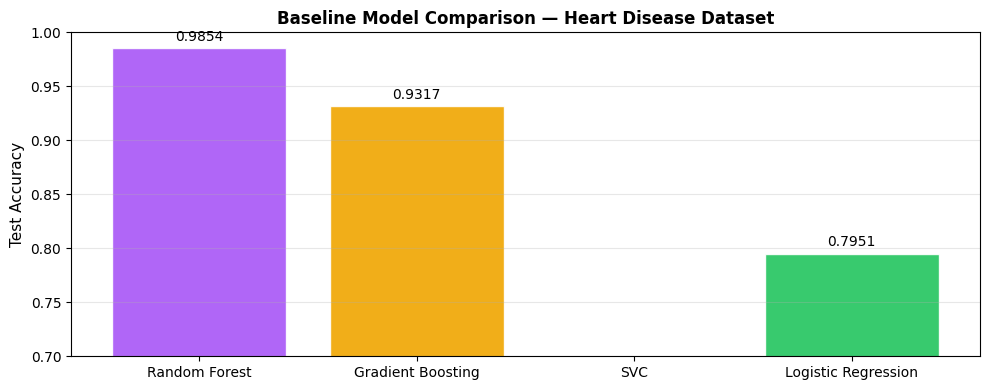

In [16]:
# Visual comparison
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#a855f7', '#f0a500', '#3b82f6', '#22c55e']
bars = ax.bar(baseline_accs.keys(), baseline_accs.values(),
              color=colors, alpha=0.9, edgecolor='white')
ax.bar_label(bars, fmt='%.4f', fontsize=10, padding=3)
ax.set_ylim(0.7, 1.0)
ax.set_ylabel('Test Accuracy', fontsize=11)
ax.set_title('Baseline Model Comparison — Heart Disease Dataset', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# Quick test: non-default max_samples
rf_75 = RandomForestClassifier(max_samples=0.75, random_state=42)
rf_75.fit(X_train_h, y_train_h)

acc_75 = accuracy_score(y_test_h, rf_75.predict(X_test_h))
cv_75  = cross_val_score(rf_75, X_h, y_h, cv=10, scoring='accuracy').mean()

print(f"RF default     test acc: {baseline_accs['Random Forest']:.4f}")
print(f"RF max_samples=0.75:     {acc_75:.4f}  |  CV: {cv_75:.4f}")

RF default     test acc: 0.9854
RF max_samples=0.75:     0.9854  |  CV: 0.9941


<a id='grid'></a>
<div style="border-bottom: 2px solid #a855f7; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 10</span>
  <h2 style="color: #f0e6ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🧮 GridSearchCV</h2>
</div>

`GridSearchCV` tests **every combination** in the grid. With 4×3×3×3 = 108 combinations × 5 folds = **540 fits** — feasible on this small dataset (303 rows) but would be impractical on large data. Always fit on `X_train` only — never on the full dataset.

<div style="background: #0d0020; border: 1px solid #4a0080; border-radius: 8px; padding: 14px 20px; margin: 14px 0; font-size: 13px; color: #d8b4fe;">
  <strong style="color: #a855f7;">Rule of thumb:</strong> GridSearchCV is appropriate when the grid is small (&lt;200 combinations). For larger spaces, use <strong style='color:#f0e6ff;'>RandomizedSearchCV</strong> (Section 11) which gives comparable results 5–10× faster.
</div>

In [18]:
param_grid = {
    'n_estimators': [20, 60, 100, 120],
    'max_features': [0.2, 0.6, 1.0],
    'max_depth':    [2, 8, None],
    'max_samples':  [0.5, 0.75, 1.0],
}

total = 1
for v in param_grid.values():
    total *= len(v)
print(f"Grid combinations : {total}")
print(f"Total CV fits     : {total * 5} (×5 folds)")

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train_h, y_train_h)

print(f"\nBest CV Score : {rf_grid.best_score_:.4f}")
print(f"Best Params   :")
for k, v in rf_grid.best_params_.items():
    print(f"  {k:<16}: {v}")

Grid combinations : 108
Total CV fits     : 540 (×5 folds)
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best CV Score : 0.9817
Best Params   :
  max_depth       : None
  max_features    : 0.2
  max_samples     : 1.0
  n_estimators    : 60


In [19]:
best_grid_model = rf_grid.best_estimator_
grid_test_acc   = accuracy_score(y_test_h, best_grid_model.predict(X_test_h))

print(f"GridSearch best model — Test Accuracy: {grid_test_acc:.4f}")
print(f"Baseline RF          — Test Accuracy: {baseline_accs['Random Forest']:.4f}")
print(f"Improvement: {grid_test_acc - baseline_accs['Random Forest']:+.4f}")

GridSearch best model — Test Accuracy: 0.9854
Baseline RF          — Test Accuracy: 0.9854
Improvement: +0.0000


<a id='random-search'></a>
<div style="border-bottom: 2px solid #a855f7; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 11</span>
  <h2 style="color: #f0e6ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🎯 RandomizedSearchCV</h2>
</div>

`RandomizedSearchCV` samples only `n_iter` random combinations from the parameter space — instead of exhaustively testing every combination. For large grids this is much faster while finding equally good hyperparameters.

The parameter distributions below carefully **separate bootstrap=True and bootstrap=False** configurations — `max_samples` is only meaningful when `bootstrap=True`, so we use a list of two separate dicts to avoid invalid combinations.

In [20]:
import time

# Two separate dicts: one for bootstrap=True, one for bootstrap=False
param_distributions = [
    {
        'n_estimators':      [20, 60, 100, 120],
        'max_features':      [0.2, 0.6, 1.0],
        'max_depth':         [2, 8, None],
        'max_samples':       [0.5, 0.75, 1.0],   # valid only when bootstrap=True
        'bootstrap':         [True],
        'min_samples_split': [2, 5],
        'min_samples_leaf':  [1, 2],
    },
    {
        'n_estimators':      [20, 60, 100, 120],
        'max_features':      [0.2, 0.6, 1.0],
        'max_depth':         [2, 8, None],
        'max_samples':       [None],             # must be None when bootstrap=False
        'bootstrap':         [False],
        'min_samples_split': [2, 5],
        'min_samples_leaf':  [1, 2],
    },
]

rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_distributions,
    n_iter=20,          # ← 20 random combinations × 5 folds = 100 fits
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

start = time.time()
rf_random.fit(X_train_h, y_train_h)
elapsed = time.time() - start

print(f"\nSearch done in {elapsed:.1f}s")
print(f"Best CV Score : {rf_random.best_score_:.4f}")
print("Best Params   :")
for k, v in rf_random.best_params_.items():
    print(f"  {k:<22}: {v}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Search done in 7.5s
Best CV Score : 0.9817
Best Params   :
  n_estimators          : 100
  min_samples_split     : 2
  min_samples_leaf      : 1
  max_samples           : None
  max_features          : 0.6
  max_depth             : 8
  bootstrap             : False


In [21]:
random_test_acc = accuracy_score(y_test_h, rf_random.best_estimator_.predict(X_test_h))

# Summary comparison
print(f"{'Method':<30} {'Test Acc':>10}")
print("-" * 42)
print(f"{'Baseline RF':<30} {baseline_accs['Random Forest']:>10.4f}")
print(f"{'GridSearchCV best':<30} {grid_test_acc:>10.4f}")
print(f"{'RandomizedSearchCV best':<30} {random_test_acc:>10.4f}")

# Top 5 Randomized search results
results_df = pd.DataFrame(rf_random.cv_results_).sort_values('rank_test_score').head(5)
print(f"\nTop 5 RandomizedSearch combinations:")
print(results_df[['param_n_estimators','param_max_depth','param_max_features',
                   'mean_test_score']].round(4).to_string(index=False))

Method                           Test Acc
------------------------------------------
Baseline RF                        0.9854
GridSearchCV best                  0.9854
RandomizedSearchCV best            0.9854

Top 5 RandomizedSearch combinations:
 param_n_estimators param_max_depth  param_max_features  mean_test_score
                100               8                 0.6           0.9817
                100            None                 0.2           0.9817
                100            None                 1.0           0.9805
                120               8                 1.0           0.9756
                 20            None                 1.0           0.9744


<a id='oob'></a>
<div style="border-bottom: 2px solid #a855f7; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 12</span>
  <h2 style="color: #f0e6ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🪂 OOB Score — Out-of-Bag Evaluation</h2>
</div>

Because bootstrap sampling selects ~63% of training rows per tree, each training sample is excluded from ~37% of trees on average. Those trees — the ones that never trained on a given sample — can be used to predict that sample. The average accuracy of these OOB predictions is the **OOB score**.

<div style="background: #0d0020; border: 1px solid #4a0080; border-radius: 10px; padding: 18px 22px; margin: 16px 0; font-size: 13px;">
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 16px;">
    <div>
      <div style="color: #a855f7; font-weight: 700; margin-bottom: 6px;">🌱 Why it's free</div>
      <div style="color: #d8b4fe; line-height: 1.7;">The OOB samples are a by-product of bootstrap sampling — no additional data splitting needed. Setting <code>oob_score=True</code> adds minimal computation overhead.</div>
    </div>
    <div>
      <div style="color: #a855f7; font-weight: 700; margin-bottom: 6px;">📊 OOB vs Test Accuracy</div>
      <div style="color: #d8b4fe; line-height: 1.7;">OOB score ≈ test accuracy in practice. Each sample is evaluated by ~37% of trees — roughly equivalent to 5-fold cross-validation. Use it when you don't have a separate test set.</div>
    </div>
  </div>
</div>

In [22]:
rf_oob = RandomForestClassifier(oob_score=True, n_estimators=100, random_state=42)
rf_oob.fit(X_train_h, y_train_h)

oob_acc  = rf_oob.oob_score_
test_acc = accuracy_score(y_test_h, rf_oob.predict(X_test_h))

print(f"OOB Score  (no test set used)  : {oob_acc:.4f}")
print(f"Test Score (explicit test set) : {test_acc:.4f}")
print(f"Difference                     : {abs(oob_acc - test_acc):.4f}")
print(f"\n→ OOB tracks test accuracy closely — a reliable free validation estimate.")

OOB Score  (no test set used)  : 0.9939
Test Score (explicit test set) : 0.9854
Difference                     : 0.0085

→ OOB tracks test accuracy closely — a reliable free validation estimate.


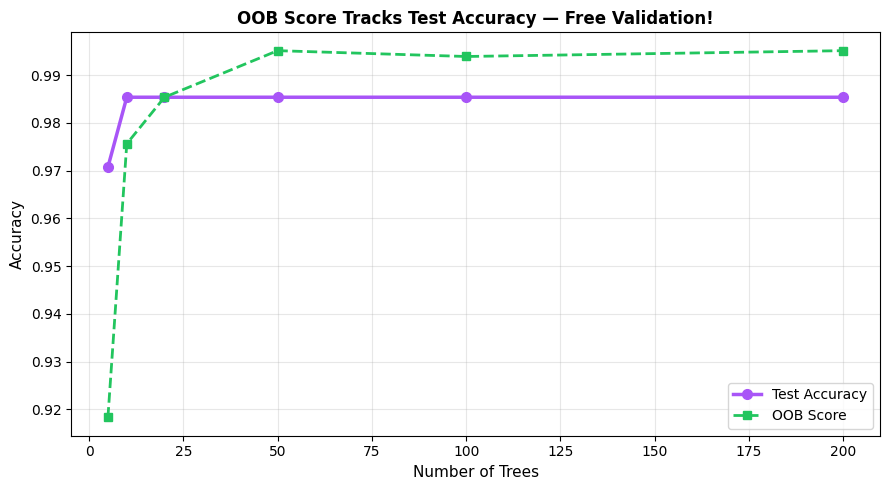

In [23]:
# Show OOB score vs test accuracy as n_estimators increases
n_vals = [5, 10, 20, 50, 100, 200]
oob_scores, test_scores = [], []

for n in n_vals:
    rf_n = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42)
    rf_n.fit(X_train_h, y_train_h)
    oob_scores.append(rf_n.oob_score_)
    test_scores.append(accuracy_score(y_test_h, rf_n.predict(X_test_h)))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_vals, test_scores, 'o-', color='#a855f7', linewidth=2.5, markersize=7, label='Test Accuracy')
ax.plot(n_vals, oob_scores,  's--', color='#22c55e', linewidth=2, markersize=6, label='OOB Score')
ax.set_xlabel('Number of Trees', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('OOB Score Tracks Test Accuracy — Free Validation!', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<a id='importance'></a>
<div style="border-bottom: 2px solid #a855f7; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 13</span>
  <h2 style="color: #f0e6ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🧠 Feature Importance — MNIST Pixel Heatmap</h2>
</div>

Random Forest provides `feature_importances_` — a measure of how much each feature contributes to impurity reduction across all trees and all splits. On the MNIST digit dataset (784 pixel features = 28×28 images), we can **reshape the 784 importance values back to 28×28** and visualise which pixels matter most for digit recognition. Pixels in the centre of the image (where digit strokes are) should be most important.

In [24]:
df_mnist = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

X_m = df_mnist.drop(columns=['label'])
y_m = df_mnist['label']

print(f"MNIST Shape: {X_m.shape}")
print(f"Classes    : {sorted(y_m.unique())}")
print(f"Features   : 784 pixels (28×28 images)")

MNIST Shape: (42000, 784)
Classes    : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Features   : 784 pixels (28×28 images)


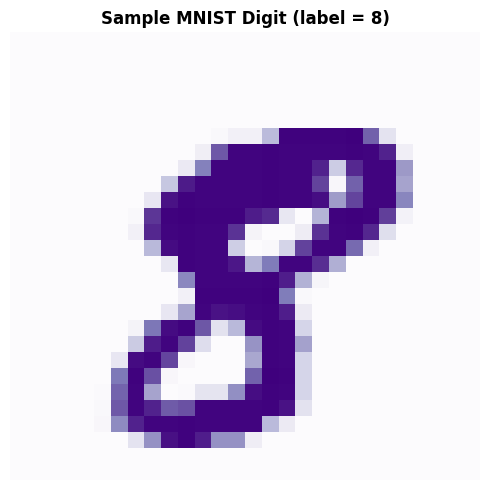

In [25]:
# Show a sample digit
sample_idx = 10
fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(X_m.iloc[sample_idx].values.reshape(28, 28),
            cmap='Purples', ax=ax, cbar=False)
ax.set_title(f'Sample MNIST Digit (label = {y_m.iloc[sample_idx]})', fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

In [26]:
# Train Random Forest on full MNIST training set
rf_mnist = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_mnist.fit(X_m, y_m)

print(f"OOB Score: {rf_mnist.oob_score_:.4f}" if hasattr(rf_mnist, 'oob_score_')
      else f"Fitted on {X_m.shape[0]:,} samples, {X_m.shape[1]} features")
print(f"feature_importances_ shape: {rf_mnist.feature_importances_.shape}")

Fitted on 42,000 samples, 784 features
feature_importances_ shape: (784,)


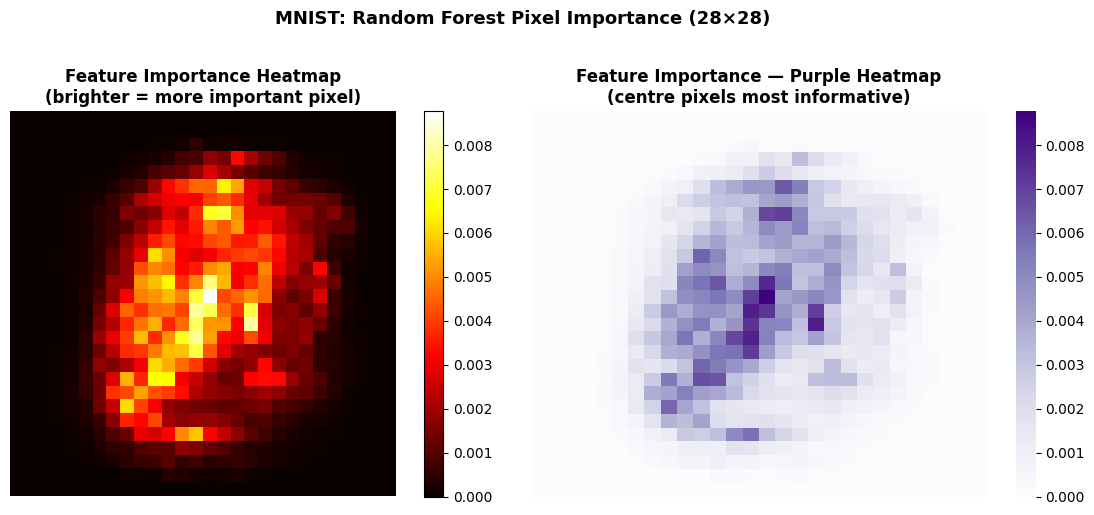


Most important pixel position : (np.int64(13), np.int64(14))
Least important (corners)     : 0.000000 (top-left corner)
Most important value          : 0.008775


In [27]:
# Reshape 784 importances → 28×28 heatmap
importance_map = rf_mnist.feature_importances_.reshape(28, 28)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw importance values
im1 = axes[0].imshow(importance_map, cmap='hot', interpolation='nearest')
axes[0].set_title('Feature Importance Heatmap\n(brighter = more important pixel)', fontweight='bold')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0])

# Seaborn heatmap
sns.heatmap(importance_map, cmap='Purples', ax=axes[1], cbar=True,
            xticklabels=False, yticklabels=False)
axes[1].set_title('Feature Importance — Purple Heatmap\n(centre pixels most informative)', fontweight='bold')

plt.suptitle('MNIST: Random Forest Pixel Importance (28×28)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nMost important pixel position : {np.unravel_index(importance_map.argmax(), (28,28))}")
print(f"Least important (corners)     : {importance_map[0,0]:.6f} (top-left corner)")
print(f"Most important value          : {importance_map.max():.6f}")

<div style="background: #0d0020; border-left: 4px solid #a855f7; border-radius: 0 8px 8px 0; padding: 12px 18px; margin: 12px 0; font-size: 14px; color: #d8b4fe;">
  <strong style="color: #f0e6ff;">✅ Reading the heatmap:</strong> Corner pixels are dark (near zero importance) — they're almost always blank in handwritten digit images, so splitting on them gives no discriminative information. Centre-left and centre pixels are brightest — that's where pen strokes differ most between digits (e.g. the loop of 0/6/9 vs the vertical of 1 vs the curves of 2/3/5).
</div>

<a id='importance-math'></a>
<div style="border-bottom: 2px solid #a855f7; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 14</span>
  <h2 style="color: #f0e6ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🧮 How Feature Importance Is Calculated</h2>
</div>

sklearn's default `feature_importances_` uses **Mean Decrease in Impurity (MDI)**. For each split on feature j, the weighted impurity reduction is:

<div style="background: #0d0020; border: 1px solid #4a0080; border-radius: 12px; padding: 22px 28px; margin: 16px 0; text-align: center;">
  <div style="color: #a855f7; font-size: 18px; font-family: Georgia, serif; font-weight: 700; margin-bottom: 12px;">
    ΔI(node) = I(parent) − wₗ·I(left) − wᵣ·I(right)
  </div>
  <div style="color: #d8b4fe; font-size: 13px; line-height: 1.7;">
    <strong style='color:#f0e6ff;'>I</strong> = impurity (Gini or entropy) &nbsp;·&nbsp;
    <strong style='color:#f0e6ff;'>w</strong> = fraction of samples reaching that child<br/>
    Feature importance = sum of ΔI across all nodes where that feature was used, across all trees → normalised to sum to 1.
  </div>
</div>

Single Decision Tree feature importances:
  Feature 0: 1.0000
  Feature 1: 0.0000


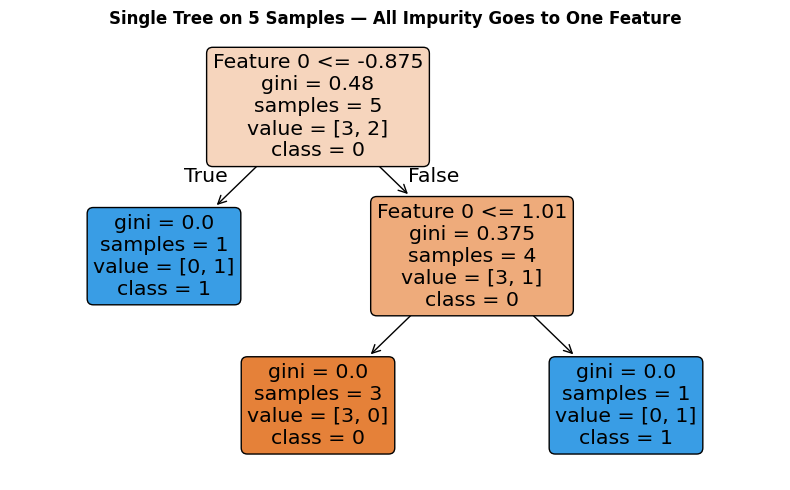

In [28]:
# Tiny example: 5 samples, 2 features — easy to inspect
X_tiny, y_tiny = make_classification(
    n_samples=5, n_classes=2,
    n_features=2, n_informative=2, n_redundant=0, random_state=0
)

# Single tree
clf_tiny = DecisionTreeClassifier(random_state=42)
clf_tiny.fit(X_tiny, y_tiny)

print("Single Decision Tree feature importances:")
for i, imp in enumerate(clf_tiny.feature_importances_):
    print(f"  Feature {i}: {imp:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
plot_tree(clf_tiny, feature_names=['Feature 0', 'Feature 1'],
          class_names=['0', '1'], filled=True, rounded=True, ax=ax)
ax.set_title('Single Tree on 5 Samples — All Impurity Goes to One Feature', fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
# Small forest: 5 trees — see how importances average across trees
rf_tiny = RandomForestClassifier(n_estimators=5, random_state=42)
rf_tiny.fit(X_tiny, y_tiny)

print("Per-tree feature importances:")
print(f"{'':10} {'Feature 0':>12} {'Feature 1':>12}")
print("-" * 35)
for i, est in enumerate(rf_tiny.estimators_):
    f0, f1 = est.feature_importances_
    print(f"  Tree {i}      {f0:>12.4f} {f1:>12.4f}")
print("-" * 35)
f0_mean, f1_mean = rf_tiny.feature_importances_
print(f"  Forest avg  {f0_mean:>12.4f} {f1_mean:>12.4f}")
print(f"  Sum         {f0_mean+f1_mean:>12.4f}  ← always 1")

Per-tree feature importances:
              Feature 0    Feature 1
-----------------------------------
  Tree 0            0.6250       0.3750
  Tree 1            1.0000       0.0000
  Tree 2            1.0000       0.0000
  Tree 3            1.0000       0.0000
  Tree 4            0.0000       1.0000
-----------------------------------
  Forest avg        0.7250       0.2750
  Sum               1.0000  ← always 1


<div style="background: linear-gradient(135deg, #1a0030 0%, #2d0050 100%); border: 1px solid #4a0080; border-radius: 14px; padding: 36px 40px; margin-top: 32px;">
  <h2 style="color: #ffffff; font-size: 20px; font-weight: 700; margin: 0 0 8px 0;">📌 Key Concepts &amp; Takeaways</h2>
  <p style="color: #d8b4fe; font-size: 13px; margin: 0 0 20px 0;">Everything that matters about Random Forest.</p>
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 14px; margin-bottom: 20px;">
    <div style="background: rgba(168,85,247,0.08); border: 1px solid #4a0080; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #a855f7; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🌱 Bootstrap Sampling</div>
      <div style="color: #d8b4fe; font-size: 12px; line-height: 1.7;">Each tree trains on a random resample with replacement (~63% unique rows). The ~37% excluded rows are OOB — used for free validation without a separate test split.</div>
    </div>
    <div style="background: rgba(168,85,247,0.08); border: 1px solid #4a0080; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #a855f7; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🎲 Random Features per Split</div>
      <div style="color: #d8b4fe; font-size: 12px; line-height: 1.7;">At every node, only √p (classification) or p/3 (regression) features are considered. This decorrelates trees beyond plain Bagging — the main RF innovation.</div>
    </div>
    <div style="background: rgba(168,85,247,0.08); border: 1px solid #4a0080; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #a855f7; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🗳️ Aggregation</div>
      <div style="color: #d8b4fe; font-size: 12px; line-height: 1.7;">Classification → majority vote. Regression → average. Each tree's independent error averages out across the ensemble — variance drops by ~1/N for N uncorrelated trees.</div>
    </div>
    <div style="background: rgba(168,85,247,0.08); border: 1px solid #4a0080; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #a855f7; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🧠 Feature Importance</div>
      <div style="color: #d8b4fe; font-size: 12px; line-height: 1.7;">MDI = total weighted impurity reduction per feature across all trees, normalised to sum to 1. Stable and interpretable — a major advantage over SVM, KNN, or neural networks.</div>
    </div>
    <div style="background: rgba(168,85,247,0.08); border: 1px solid #4a0080; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #a855f7; font-weight: 700; font-size: 13px; margin-bottom: 6px;">⚡ RandomizedSearchCV vs Grid</div>
      <div style="color: #d8b4fe; font-size: 12px; line-height: 1.7;">For large grids use Randomized (20 combos × 5 folds = 100 fits) not Grid (108 combos × 5 folds = 540 fits). Quality is comparable; speed is 5× better.</div>
    </div>
    <div style="background: rgba(168,85,247,0.08); border: 1px solid #4a0080; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #a855f7; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🪂 OOB Score</div>
      <div style="color: #d8b4fe; font-size: 12px; line-height: 1.7;">Always enable <code>oob_score=True</code> when bootstrap=True. It's a free, reliable generalisation estimate — each sample evaluated by trees that never trained on it.</div>
    </div>
  </div>
  <div style="padding-top: 14px; border-top: 1px solid #4a0080; color: #d8b4fe; font-size: 12px;">
    Next up → <strong style='color:#a855f7;'>ML 50: AdaBoost — Adaptive Boosting from Scratch</strong>
  </div>
</div>